# 04 - Modelling, explainability & business impact

Run `python -m src.pipeline` first - this notebook reads what it produced
(`reports/model_comparison.json`, `reports/threshold_economics.json`, scored customers).

**Protocol:** stratified 80/20 split -> 25-draw randomised search per model family with 5-fold
stratified CV on the training split (optimising ROC-AUC) -> money-optimal threshold chosen on
out-of-fold training predictions -> the test split is scored once, at the end.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display
from src import config
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
report = json.loads(config.METRICS_JSON.read_text())
econ = json.loads(config.THRESHOLD_JSON.read_text())
print("champion:", report["champion"])

champion: XGBoost


## Model comparison

In [2]:
rows = []
for name, m in report["models"].items():
    d = m["test_at_0.5"]
    rows.append({"model": name,
                 "cv_roc_auc": m["cv"]["roc_auc_mean"], "cv_std": m["cv"]["roc_auc_std"],
                 "test_roc_auc": d["roc_auc"], "test_pr_auc": d["pr_auc"],
                 "accuracy": d["accuracy"], "precision": d["precision"], "recall": d["recall"],
                 "f1": d["f1"], "brier": d["brier"],
                 "t*": m["optimal_threshold"],
                 "net_value_at_t*": m["campaign_test_at_optimal"]["net_value"]})
pd.DataFrame(rows).set_index("model").round(3)

,cv_roc_auc,cv_std,test_roc_auc,test_pr_auc,accuracy,precision,recall,f1,brier,t*,net_value_at_t*
model,,,,,,,,,,,
Logistic Regression,0.845,0.017,0.843,0.659,0.791,0.629,0.521,0.570,0.137,0.28,12992.214
Decision Tree,0.831,0.015,0.833,0.618,0.789,0.648,0.452,0.532,0.141,0.27,12532.332
Random Forest,0.846,0.016,0.848,0.671,0.797,0.655,0.497,0.565,0.135,0.32,12763.246
Gradient Boosting,0.848,0.017,0.847,0.667,0.796,0.647,0.511,0.571,0.135,0.32,12776.718
XGBoost,0.848,0.016,0.849,0.673,0.793,0.636,0.519,0.571,0.134,0.32,12735.838


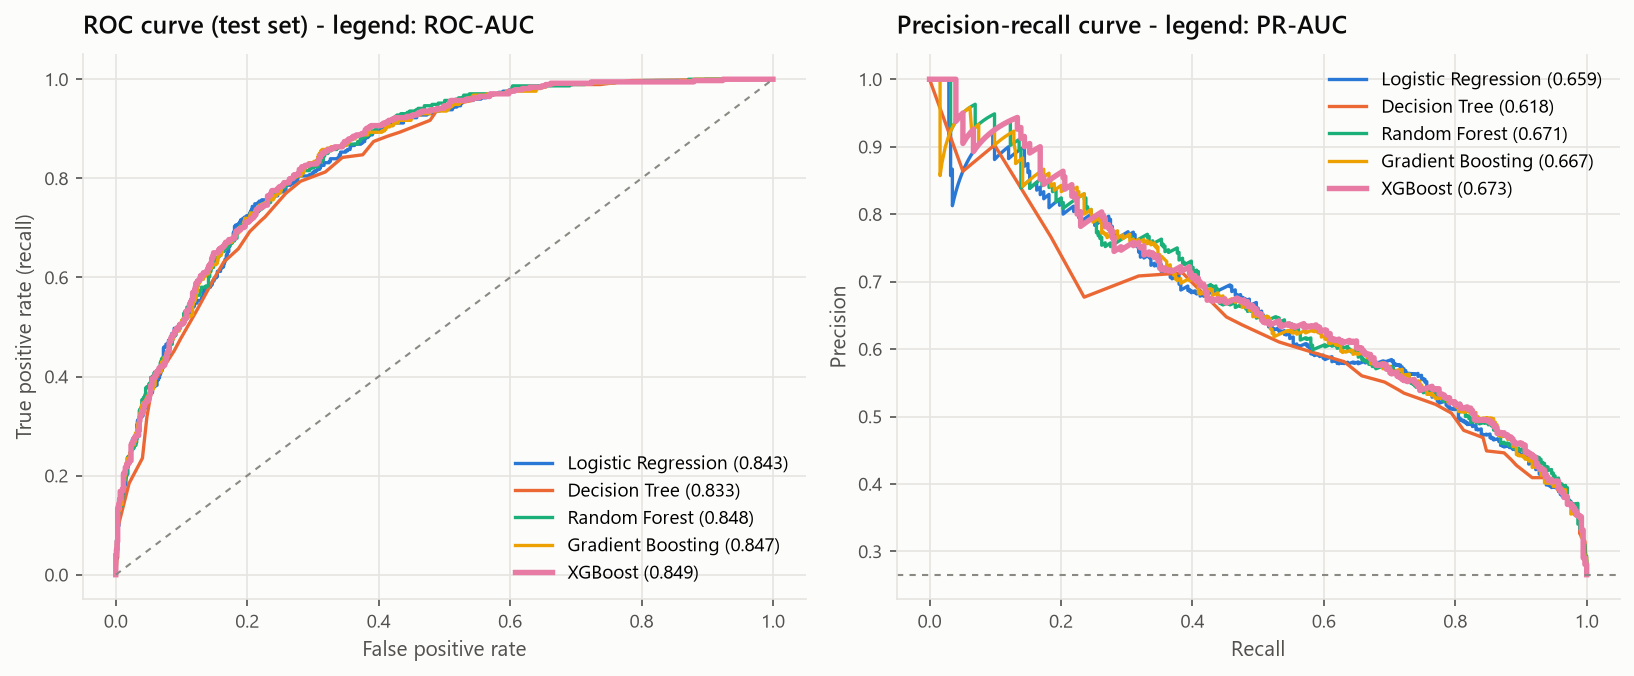

In [3]:
display(Image(str(config.FIGURES_DIR / "model_roc_pr.png")))

**XGBoost wins on the pre-registered criterion (CV ROC-AUC 0.8485), but the top four models are
within 0.004 of each other - a quarter of one CV standard deviation.** This is typical for Telco
churn: a handful of strong, roughly monotonic drivers carry the signal, so a regularised logistic
regression is almost as good as boosted trees (the tuned XGBoost uses depth-2 trees, i.e. mostly
pairwise interactions). The single decision tree is clearly behind.

Net value at each model's own threshold differs by a few hundred dollars (logistic regression is
actually highest on the test set) - noise at this sample size, which is exactly why the champion
was chosen on cross-validation and not on the test set. In production, logistic regression would
be a perfectly defensible, simpler choice.

## Calibration - can the probabilities be used as money?

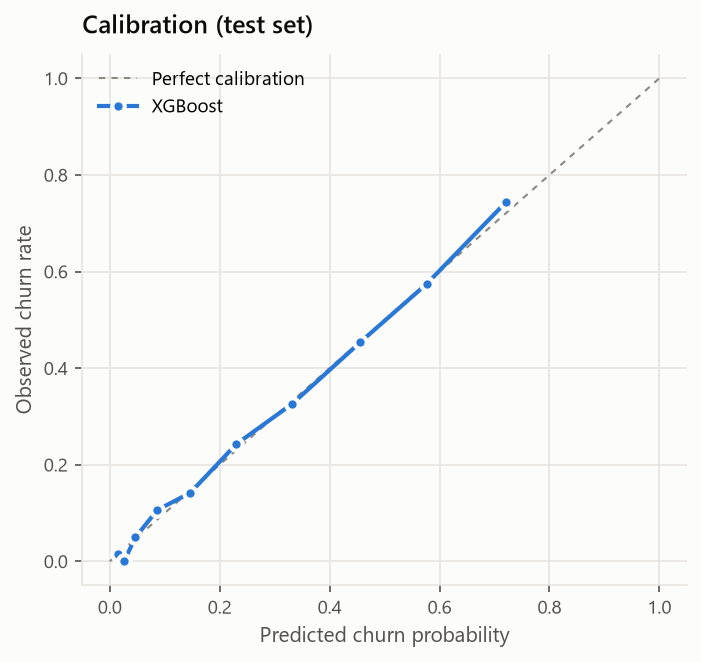

,model,class_weighting,cv_roc_auc,cv_brier,mean_predicted_prob,actual_churn_rate,optimal_threshold,test_net_value
0,Logistic Regression,none,0.8448,0.1356,0.2652,0.2654,0.28,12992.214
1,Logistic Regression,balanced,0.8444,0.1656,0.4134,0.2654,0.53,13091.308
2,XGBoost,none,0.8485,0.1340,0.2654,0.2654,0.32,12735.838
3,XGBoost,balanced,0.8481,0.1628,0.4120,0.2654,0.57,12811.106


In [4]:
display(Image(str(config.FIGURES_DIR / "model_calibration.png")))
pd.DataFrame(report["imbalance_experiment"]).round(4)

The unweighted XGBoost model is well calibrated: predicted deciles sit on the diagonal.

Re-weighting the classes (`class_weight="balanced"` / `scale_pos_weight`) leaves ranking
unchanged (ROC-AUC 0.8481 vs. 0.8485) and - once each variant gets its own money-optimal
threshold - earns the same net value within noise (+$75 on ~$12.7k). What it does change is the
probability scale: the average prediction jumps from 26.5% (the true rate) to 41%, and the Brier
score worsens from 0.134 to 0.163. Because expected loss = probability x value, the project keeps
the unweighted, calibrated model and handles imbalance at the **decision threshold**.

## Choosing the threshold with money, not accuracy

{
  "offer_cost": 20.0,
  "save_rate": 0.3,
  "horizon_months": 12,
  "gross_margin": 0.3
}


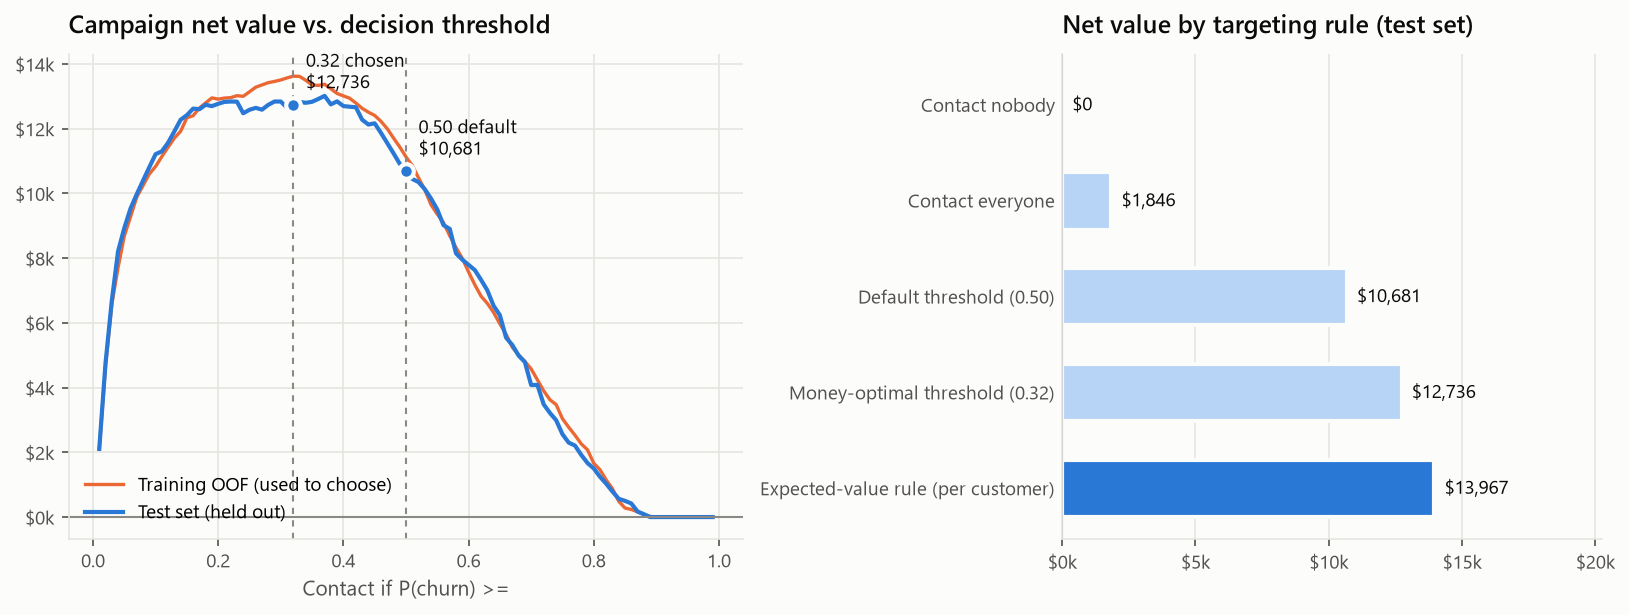

,policy,contacted,churners_caught,precision,recall,retained_value,campaign_cost,net_value
0,Contact nobody,0,0,0.000,0.000,0.000,0.0,0.000
1,Contact everyone,1409,374,0.265,1.000,30025.836,28180.0,1845.836
2,Default threshold (0.50),305,194,0.636,0.519,16781.364,6100.0,10681.364
3,Money-optimal threshold (0.32),508,278,0.547,0.743,22895.838,10160.0,12735.838
4,Expected-value rule (per customer),535,277,0.518,0.741,24666.822,10700.0,13966.822


In [5]:
print(json.dumps(econ["economics"], indent=2))
display(Image(str(config.FIGURES_DIR / "threshold_economics.png")))
pd.DataFrame(econ["policy_comparison_test"])[["policy", "contacted", "churners_caught",
    "precision", "recall", "retained_value", "campaign_cost", "net_value"]].round(3)

- The threshold was chosen on **training out-of-fold** predictions (0.32) and the two curves
  overlap almost perfectly on the test set, so the choice generalises.
- At 0.32 the campaign reaches 278 of 374 churners (74% recall) instead of 194 (52%) at 0.50,
  for **+$2,054 net value (+19%)** on 1,409 customers.
- The optimum is a broad plateau (roughly 0.2-0.45): the lesson is less "0.32 exactly" than
  "never default to 0.5 when a miss costs much more than a false alarm".
- The per-customer **expected-value rule** (contact when P x save rate x value > offer cost)
  does better still (+31% vs. 0.5), because it spends the offer budget on valuable customers.
  It only works because the probabilities are calibrated.

## Explainability - global

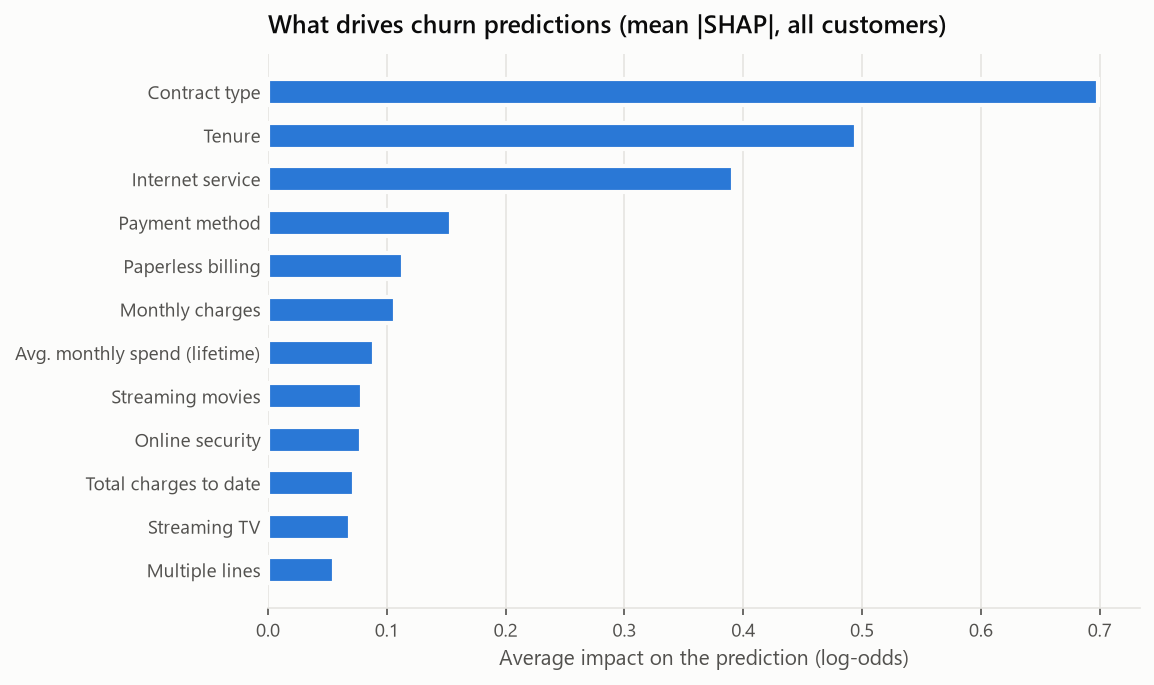

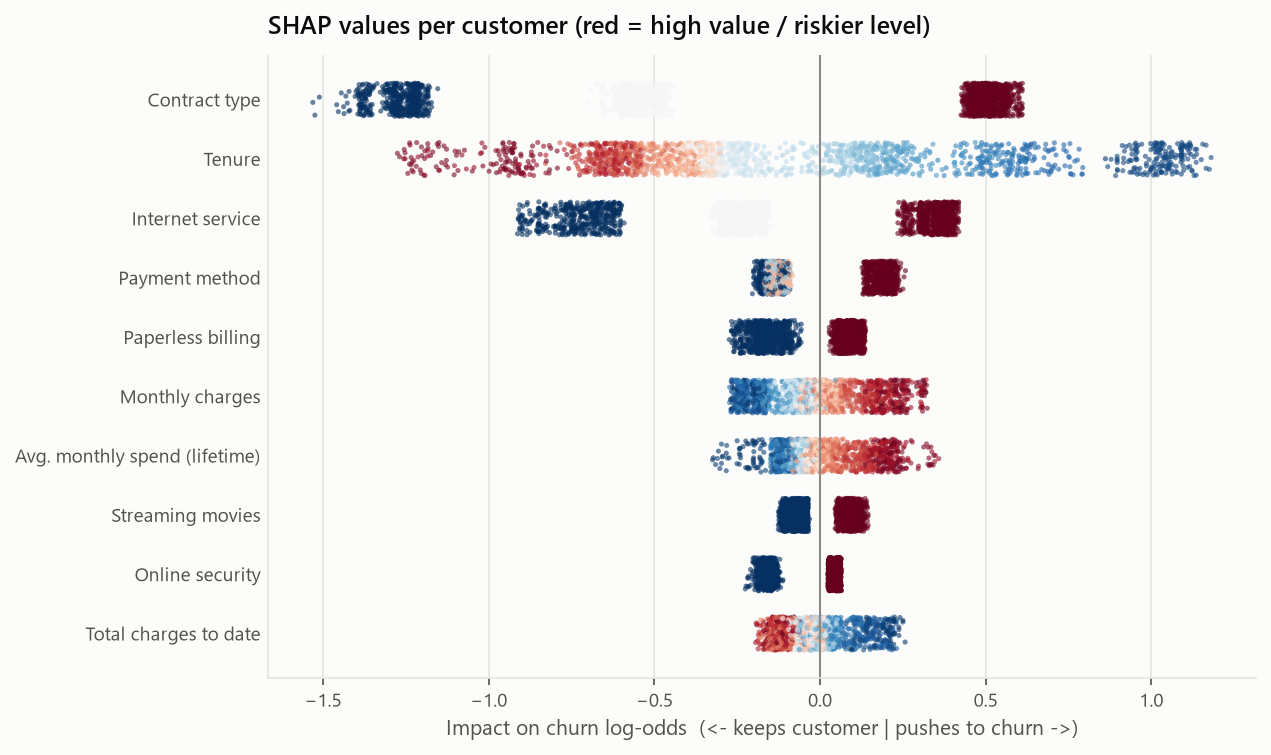

,feature,importance_mean,importance_std
0,contract,0.0740,0.0095
1,tenure,0.0577,0.0075
2,internet_service,0.0373,0.0068
3,payment_method,0.0036,0.0012
4,online_security,0.0028,0.0008
5,paperless_billing,0.0027,0.0014
6,avg_monthly_spend,0.0026,0.0011
7,monthly_charges,0.0022,0.0011
8,streaming_movies,0.0016,0.0003
9,streaming_tv,0.0015,0.0009


In [6]:
display(Image(str(config.FIGURES_DIR / "shap_global_importance.png")))
display(Image(str(config.FIGURES_DIR / "shap_beeswarm.png")))
pd.read_csv(config.REPORTS_DIR / "permutation_importance.csv").head(10).round(4)

## Explainability - one customer, and the example prediction output

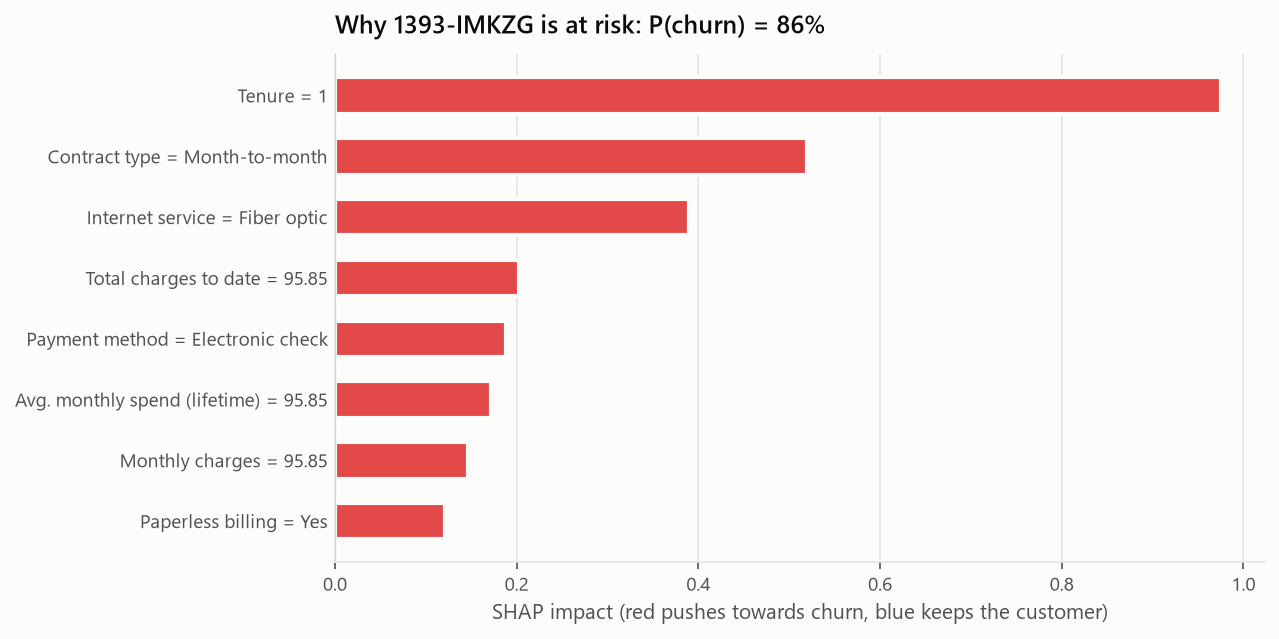

Customer ID: 1393-IMKZG

Churn Probability: 85.9%
Risk Level: HIGH
Expected margin loss (12 months): $296

Major Risk Factors:
1. Short tenure (only 1 month)
2. Month-to-month contract
3. Fiber-optic internet plan

Recommended Action:
Early-life onboarding call: check the setup, walk through the bill
Offer a discounted 12-month contract


In [7]:
display(Image(str(config.FIGURES_DIR / "shap_customer_example.png")))
scored = pd.read_csv(config.SCORED_CSV)
active = scored[scored["churn"] == 0].sort_values("expected_loss", ascending=False)
c = active.iloc[0]
print(f"""Customer ID: {c.customer_id}

Churn Probability: {c.churn_probability:.1%}
Risk Level: {c.risk_level}
Expected margin loss (12 months): ${c.expected_loss:,.0f}

Major Risk Factors:
1. {c.reason_1}
2. {c.reason_2}
3. {c.reason_3}

Recommended Action:
{c.recommended_action.replace(' | ', chr(10))}""")

## Who to call first - ranked by expected loss

In [8]:
cols = ["customer_id", "churn_probability", "risk_level", "expected_loss", "contract", "tenure",
        "monthly_charges", "top_reasons"]
active[active["contact_recommended"]][cols].head(15).round(3)

,customer_id,churn_probability,risk_level,expected_loss,contract,tenure,monthly_charges,top_reasons
959,1393-IMKZG,0.859,HIGH,296.283,Month-to-month,1,95.85,Short tenure (only 1 month); Month-to-month co...
1413,2081-VEYEH,0.756,HIGH,293.992,Month-to-month,3,107.95,Short tenure (only 3 months); Month-to-month c...
1308,1941-HOSAM,0.870,HIGH,282.350,Month-to-month,1,90.10,Short tenure (only 1 month); Month-to-month co...
5087,7145-FEJWU,0.742,HIGH,281.425,Month-to-month,12,105.30,Month-to-month contract; Fiber-optic internet ...
3641,5150-ITWWB,0.821,HIGH,280.274,Month-to-month,3,94.85,Short tenure (only 3 months); Month-to-month c...
4079,5760-IFJOZ,0.717,HIGH,278.583,Month-to-month,3,107.95,Short tenure (only 3 months); Month-to-month c...
5367,7577-SWIFR,0.867,HIGH,278.487,Month-to-month,1,89.25,Short tenure (only 1 month); Month-to-month co...
2301,3292-PBZEJ,0.689,HIGH,276.305,Month-to-month,11,111.40,Month-to-month contract; Fiber-optic internet ...
4792,6734-GMPVK,0.727,HIGH,275.551,Month-to-month,5,105.30,Short tenure (only 5 months); Month-to-month c...
2900,4132-KALRO,0.742,HIGH,269.301,Month-to-month,4,100.85,Short tenure (only 4 months); Month-to-month c...


In [9]:
print(f"active customers: {len(active):,}")
print(f"recommended for contact: {active['contact_recommended'].sum():,}")
print(f"expected margin loss, all active: ${active['expected_loss'].sum():,.0f}")
print(f"  ...of which in the contact list: ${active.loc[active['contact_recommended'], 'expected_loss'].sum():,.0f}")

active customers: 5,174
recommended for contact: 1,145
expected margin loss, all active: $246,132
  ...of which in the contact list: $155,320


## Segments

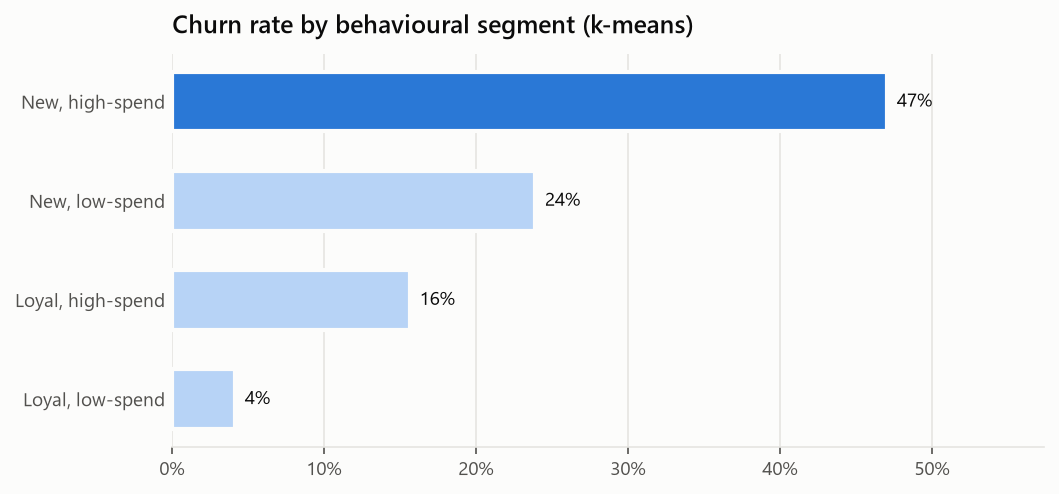

,segment,customers,churn_rate,avg_tenure,avg_monthly_charges,avg_services,share_of_customers,active_customers,avg_churn_probability,expected_loss_active
0,"New, high-spend",2410,0.470,14.920,77.298,4.246,0.342,1277,0.463,128122.465
1,"New, low-spend",1509,0.239,10.252,29.209,1.656,0.214,1149,0.234,24915.658
2,"Loyal, high-spend",2152,0.156,57.444,91.297,6.723,0.306,1816,0.164,86749.487
3,"Loyal, low-spend",972,0.041,54.468,30.125,2.062,0.138,932,0.051,6344.119


In [10]:
display(Image(str(config.FIGURES_DIR / "segments.png")))
pd.read_csv(config.REPORTS_DIR / "segment_profile.csv").round(3)

## From SHAP reasons to a retention message (LLM)

In [11]:
for ex in json.loads(config.LLM_EXAMPLES_JSON.read_text())[:2]:
    print(ex["context"]["customer_id"], "| source:", ex["brief"]["source"])
    print("SUMMARY:", ex["brief"]["summary"])
    print("MESSAGE:", ex["brief"]["customer_message"], end="\n\n")

1393-IMKZG | source: template
SUMMARY: 1393-IMKZG is HIGH risk with a churn probability of 86%, putting about $296 of margin at stake over the next year. The main drivers are short tenure (only 1 month), month-to-month contract and fiber-optic internet plan. Lead with: early-life onboarding call: check the setup, walk through the bill.
MESSAGE: Hi, thank you for being with us. We'd like to set up a quick call to make sure everything works as it should and walk you through your bill. Just reply to this message or give us a call and we'll sort it out. - The Customer Care Team

2081-VEYEH | source: template
SUMMARY: 2081-VEYEH is HIGH risk with a churn probability of 76%, putting about $294 of margin at stake over the next year. The main drivers are short tenure (only 3 months), month-to-month contract and fiber-optic internet plan. Lead with: early-life onboarding call: check the setup, walk through the bill.
MESSAGE: Hi, thank you for being with us for the past 3 months. We'd like to se

The LLM never sees raw data - only the model's probability, the SHAP reasons and the approved
playbook actions - and is told not to invent offers. Without an `ANTHROPIC_API_KEY` the same
fields come from a deterministic template.